In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("/content/seattle-weather.csv")

In [3]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
df.isnull()

,date,precipitation,temp_max,temp_min,wind,weather
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
1456,False,False,False,False,False,False
1457,False,False,False,False,False,False
1458,False,False,False,False,False,False
1459,False,False,False,False,False,False


In [5]:
print(df.isnull().sum())

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


In [6]:
features=['precipitation','temp_min','wind']
x=df[features]
y=df['temp_max']

In [7]:
x_train, x_test, y_train, y_test= train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [8]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [9]:
y_pred=model.predict(x_test)

In [10]:
y_pred

array([20.63589494, 13.87917095, 12.04945265, 22.064648  , 15.38688164,
       23.43037223, 26.34245233, 11.11303255, 18.88391227, 19.89491221,
       23.38150721, 23.42626475, 19.97286483, 22.86431219, 10.19301965,
       11.33743945, 20.56278705, 13.96208382, 16.01992576,  7.46978615,
       18.4343294 , 16.52866592, 21.46696377,  3.82653976, 23.35912843,
       12.5161241 ,  8.65237273, 16.26260395,  8.36742028, 26.99391998,
       18.31013839, 23.38150721, 17.29202742,  5.6259688 , 24.22592894,
       15.2264831 , 17.30726337,  1.92819917, 21.21868579, 18.58650785,
       15.27756623, 20.14107869, 14.65830901, 25.38613675, 16.73255814,
       15.991097  , 14.18418257,  8.99053758, 25.56727841, 21.4579379 ,
       21.32366527, 18.46606398, 20.80895353, 20.77802474,  8.25552643,
       16.64815554, 12.9022074 , 25.52040937, 10.66132675, 22.61814571,
       13.2131906 , 24.96691167,  6.58752126,  3.58037328, 24.02452   ,
       18.65364417, 11.98209934, 26.99391998, 12.35952344, 16.12

In [20]:
mse=mean_squared_error(y_test,y_pred)
mse

11.10351869094823

In [12]:
print("coefficient",model.coef_)

coefficient [-0.16520142  1.25817775 -0.22378771]


In [13]:
print("intercept",model.intercept_)

intercept 7.274348786087858


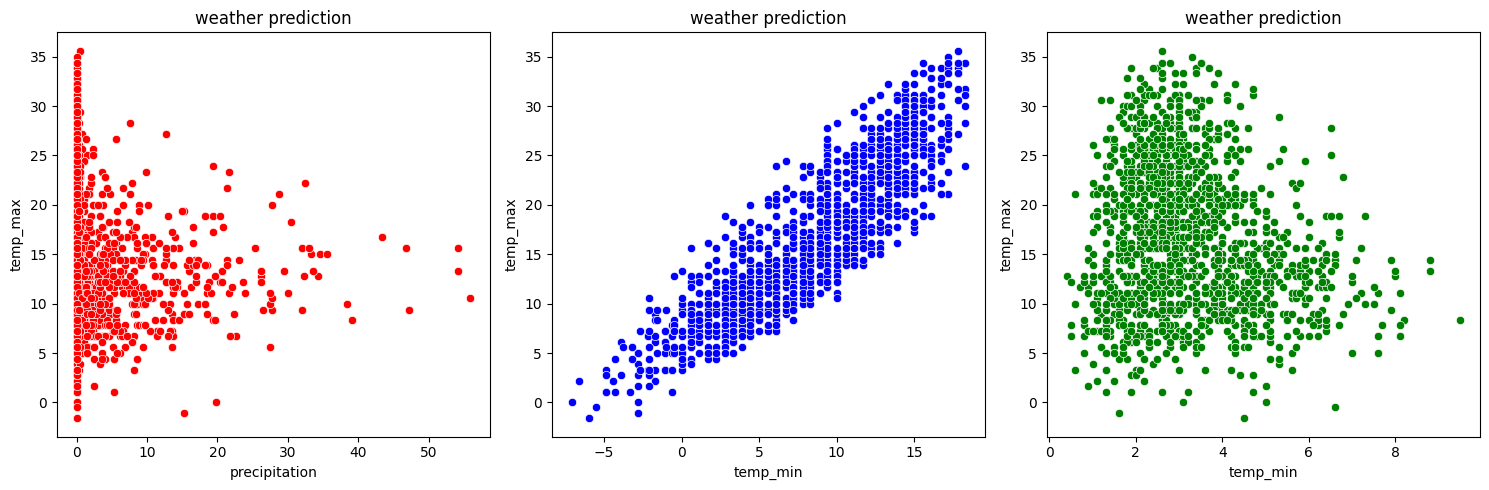

In [14]:
plt.figure(figsize=(15,5))
#precipitation vs temp_max
plt.subplot(1,3,1)
sns.scatterplot(x=x['precipitation'],y=y,color="red")
plt.title("weather prediction")
plt.xlabel("precipitation")
plt.ylabel("temp_max")

#temp_min vs temp_max
plt.subplot(1,3,2)
sns.scatterplot(x=x['temp_min'],y=y,color="blue")
plt.title("weather prediction")
plt.xlabel("temp_min")
plt.ylabel("temp_max")

#wind vs temp_max
plt.subplot(1,3,3)
sns.scatterplot(x=x['wind'],y=y,color="green")
plt.title("weather prediction")
plt.xlabel("temp_min")
plt.ylabel("temp_max")

plt.tight_layout()
plt.show()



In [16]:
from sklearn.linear_model import SGDRegressor
model = SGDRegressor(max_iter=1000, learning_rate="constant", eta0=0.0001, warm_start=True)

losses = []
epochs = 100

for epoch in range(epochs):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    loss = mean_squared_error(y_test, y_pred)
    losses.append(loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {loss}")

Epoch 1/100 - Loss: 12.188728767634402
Epoch 2/100 - Loss: 11.72071115185551
Epoch 3/100 - Loss: 11.630919275388736
Epoch 4/100 - Loss: 11.392471008385277
Epoch 5/100 - Loss: 11.348124412768241
Epoch 6/100 - Loss: 11.330925580846673
Epoch 7/100 - Loss: 11.336537652393526
Epoch 8/100 - Loss: 11.280236899797632
Epoch 9/100 - Loss: 11.286057557491032
Epoch 10/100 - Loss: 11.229802452840625
Epoch 11/100 - Loss: 11.32104291710172
Epoch 12/100 - Loss: 11.36239561433213
Epoch 13/100 - Loss: 11.23761870748752
Epoch 14/100 - Loss: 11.157855665059998
Epoch 15/100 - Loss: 11.207645092817765
Epoch 16/100 - Loss: 11.201609402928604
Epoch 17/100 - Loss: 11.142681588673405
Epoch 18/100 - Loss: 11.223699152578101
Epoch 19/100 - Loss: 11.140088241265948
Epoch 20/100 - Loss: 11.140856403279258
Epoch 21/100 - Loss: 11.202207570989673
Epoch 22/100 - Loss: 11.197904786699485
Epoch 23/100 - Loss: 11.175244842167945
Epoch 24/100 - Loss: 11.136821330866972
Epoch 25/100 - Loss: 11.38169387247347
Epoch 26/100 -

In [17]:
lr=LinearRegression()
lr.fit(x_train,y_train)
print(mean_squared_error(y_test,lr.predict(x_test)))

11.10351869094823


In [18]:
loss

11.08780127866191

In [19]:
r2=r2_score(y_test,y_pred)
r2

0.8051625227439604